# Notebook 02 — Exploratory Data Analysis (EDA)

- Understand the cleaned dataset
- Analyze the target variable `Job_Accepted`
- Explore numerical and categorical features
- Compare accepted and rejected candidates
- Analyze skills, interview, experience and salary-related patterns
- Identify correlations with job acceptance
- Generate summary tables for the next modeling stage


## 1. Import Libraries, Define Variables, and Configure Paths

In [ ]:
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

warnings.filterwarnings("ignore")


target = "Job_Accepted"


PROJECT_ROOT = Path(os.getcwd()).resolve().parent

DATA_PATH = PROJECT_ROOT / "data" / "processed" / "cleaned_job_acceptance_data.csv"

if not DATA_PATH.exists():
    PROJECT_ROOT = Path(os.getcwd()).resolve()
    DATA_PATH = PROJECT_ROOT / "data" / "processed" / "cleaned_job_acceptance_data.csv"

OUTPUT_DIR = PROJECT_ROOT / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

print("Project root:", PROJECT_ROOT)
print("Cleaned dataset:", DATA_PATH)
print("Dataset exists:", DATA_PATH.exists())
print("Target column:", target)

Project root: D:\job acceptance prediction system
Cleaned dataset: D:\job acceptance prediction system\data\processed\cleaned_job_acceptance_data.csv
Dataset exists: True
Target column: Job_Accepted


## 2. Load the Cleaned Dataset

In [2]:
df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("Target column:", target)

if target not in df.columns:
    raise KeyError(
        f"Target column '{target}' was not found. "
        f"Available columns are: {df.columns.tolist()}"
    )

display(df.head())

Dataset loaded successfully.
Rows: 49860
Columns: 36
Target column: Job_Accepted


,Candidate_ID,Age,Gender,Education_Level,Degree_Field,University_Tier,CGPA,Years_of_Experience,Previous_Companies,Internship_Experience,...,Relocation_Willingness,Competition_Level,Expected_Salary,Offered_Salary,Career_Growth_Score,Benefits_Score,Job_Security_Score,Notice_Period_Days,Offer_to_Joining_Days,Job_Accepted
0,CAND00001,28.0,Male,Diploma,Computer Science,Tier 2,7.60,5.2,3.0,No,...,Yes,Medium,1225000.0,1198000.0,92.1,62.0,77.5,30,54,0
1,CAND00002,22.0,Female,Bachelor's,Engineering,Tier 3,7.74,1.5,0.0,No,...,No,Medium,1029000.0,1168000.0,93.8,94.6,55.4,30,44,1
2,CAND00003,30.0,Female,Master's,Business Administration,Tier 1,8.28,5.1,3.0,Yes,...,Yes,Medium,644000.0,681000.0,84.4,65.9,66.3,30,31,0
3,CAND00004,31.0,Female,Bachelor's,Data Science,Tier 2,7.96,5.5,3.0,No,...,No,Low,1166000.0,1213000.0,87.3,85.6,79.7,45,58,1
4,CAND00005,20.0,Male,Bachelor's,Computer Science,Tier 3,7.96,0.0,0.0,No,...,Yes,Medium,597000.0,666000.0,83.7,76.4,79.3,15,37,1


## 3. Basic Dataset Overview

In [3]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
for i, col in enumerate(df.columns, start=1):
    print(f"{i:02d}. {col}")

print("\nData Types:")
display(df.dtypes.to_frame("Data_Type"))

print("\nDescriptive Statistics:")
display(df.describe(include="all").T)

Dataset Shape: (49860, 36)

Column Names:
01. Candidate_ID
02. Age
03. Gender
04. Education_Level
05. Degree_Field
06. University_Tier
07. CGPA
08. Years_of_Experience
09. Previous_Companies
10. Internship_Experience
11. Certifications_Count
12. Technical_Skills_Score
13. Soft_Skills_Score
14. Skills_Match_Percentage
15. Aptitude_Score
16. Communication_Score
17. Interview_Score
18. Interview_Rounds
19. Job_Role
20. Industry
21. Company_Tier
22. Company_Size
23. Job_Type
24. Work_Mode
25. Job_Location
26. Preferred_Location
27. Relocation_Willingness
28. Competition_Level
29. Expected_Salary
30. Offered_Salary
31. Career_Growth_Score
32. Benefits_Score
33. Job_Security_Score
34. Notice_Period_Days
35. Offer_to_Joining_Days
36. Job_Accepted

Data Types:


,Data_Type
Candidate_ID,str
Age,float64
Gender,str
Education_Level,str
Degree_Field,str
University_Tier,str
CGPA,float64
Years_of_Experience,float64
Previous_Companies,float64
Internship_Experience,str



Descriptive Statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Candidate_ID,49860,49860,CAND00001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,49860.0,NaN,NaN,NaN,27.135739,4.346006,18.27,24.0,27.0,30.0,57.95
Gender,49860,3,Male,29372,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Education_Level,49860,4,Bachelor's,26046,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Degree_Field,49860,9,Computer Science,10045,NaN,NaN,NaN,NaN,NaN,NaN,NaN
University_Tier,49860,3,Tier 2,22232,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CGPA,49860.0,NaN,NaN,NaN,7.597049,1.01607,3.26,6.93,7.6,8.27,10.0
Years_of_Experience,49860.0,NaN,NaN,NaN,3.591296,2.848901,0.0,1.3,3.3,5.3,15.0
Previous_Companies,49860.0,NaN,NaN,NaN,1.870357,1.558271,0.0,1.0,2.0,3.0,9.0
Internship_Experience,49860,2,Yes,29101,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 4. Data Quality Verification

In [4]:
quality_summary = pd.DataFrame({
    "Missing_Values": df.isna().sum(),
    "Missing_Percentage": (df.isna().mean() * 100).round(2),
    "Unique_Values": df.nunique(),
    "Data_Type": df.dtypes.astype(str)
}).sort_values("Missing_Values", ascending=False)

display(quality_summary)

print("Total missing values:", int(df.isna().sum().sum()))
print("Exact duplicate rows:", int(df.duplicated().sum()))

if "Candidate_ID" in df.columns:
    print("Duplicate Candidate_ID values:", int(df["Candidate_ID"].duplicated().sum()))

,Missing_Values,Missing_Percentage,Unique_Values,Data_Type
Candidate_ID,0,0.0,49860,str
Age,0,0.0,120,float64
Gender,0,0.0,3,str
Education_Level,0,0.0,4,str
Degree_Field,0,0.0,9,str
University_Tier,0,0.0,3,str
CGPA,0,0.0,563,float64
Years_of_Experience,0,0.0,151,float64
Previous_Companies,0,0.0,10,float64
Internship_Experience,0,0.0,2,str


Total missing values: 0
Exact duplicate rows: 0
Duplicate Candidate_ID values: 0


## 5. Target Variable — Job Acceptance Distribution

,Count,Percentage
Rejected (0),18025,36.15
Accepted (1),31835,63.85


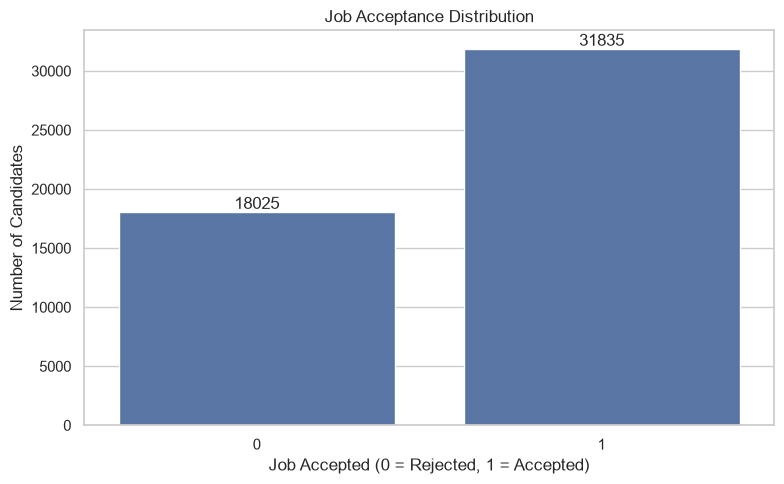

In [5]:
# Job_Accepted:
# 0 = Rejected
# 1 = Accepted

target_counts = df[target].value_counts().sort_index()
target_percent = (target_counts / len(df) * 100).round(2)

target_summary = pd.DataFrame({
    "Count": target_counts,
    "Percentage": target_percent
})

target_summary.index = [
    "Rejected (0)" if value == 0 else "Accepted (1)"
    for value in target_summary.index
]

display(target_summary)

plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=df,
    x=target,
    order=[0, 1]
)

plt.title("Job Acceptance Distribution")
plt.xlabel("Job Accepted (0 = Rejected, 1 = Accepted)")
plt.ylabel("Number of Candidates")

for container in ax.containers:
    ax.bar_label(container, fmt="%d")

plt.tight_layout()
plt.show()

## 6. Numerical Features

In [6]:
numeric_features = [
    col for col in df.select_dtypes(include=np.number).columns
    if col != target
]

print("Number of numerical features:", len(numeric_features))
print(numeric_features)

Number of numerical features: 19
['Age', 'CGPA', 'Years_of_Experience', 'Previous_Companies', 'Certifications_Count', 'Technical_Skills_Score', 'Soft_Skills_Score', 'Skills_Match_Percentage', 'Aptitude_Score', 'Communication_Score', 'Interview_Score', 'Interview_Rounds', 'Expected_Salary', 'Offered_Salary', 'Career_Growth_Score', 'Benefits_Score', 'Job_Security_Score', 'Notice_Period_Days', 'Offer_to_Joining_Days']


## 7. Numerical Feature Distributions

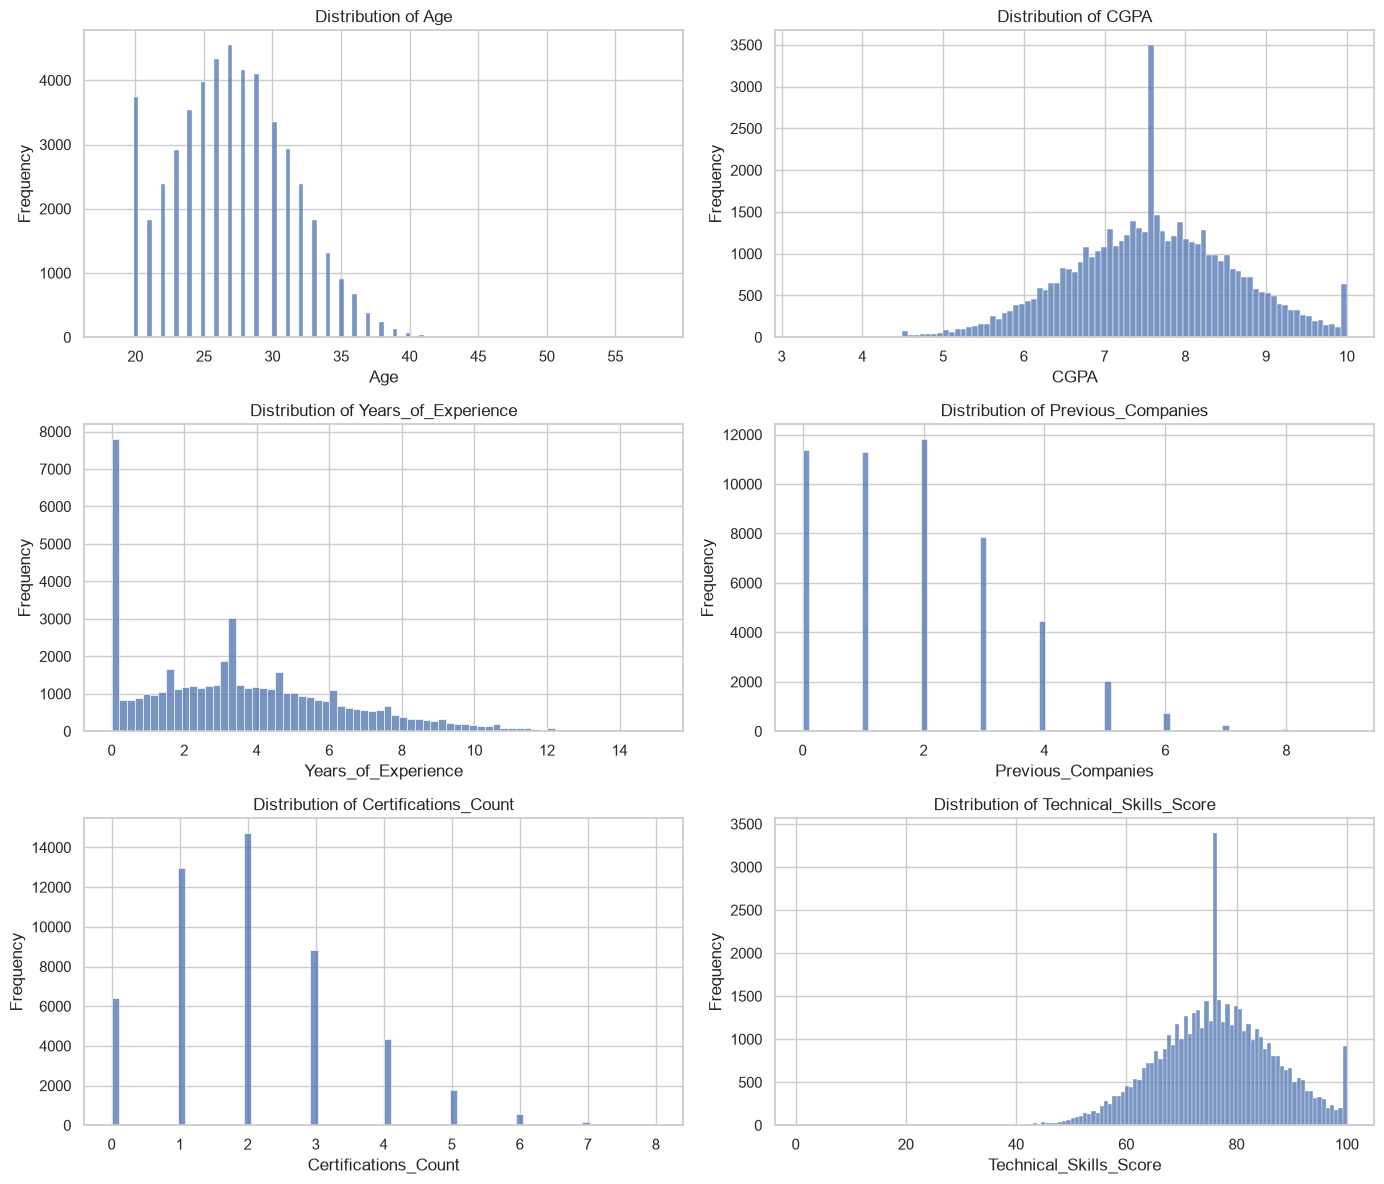

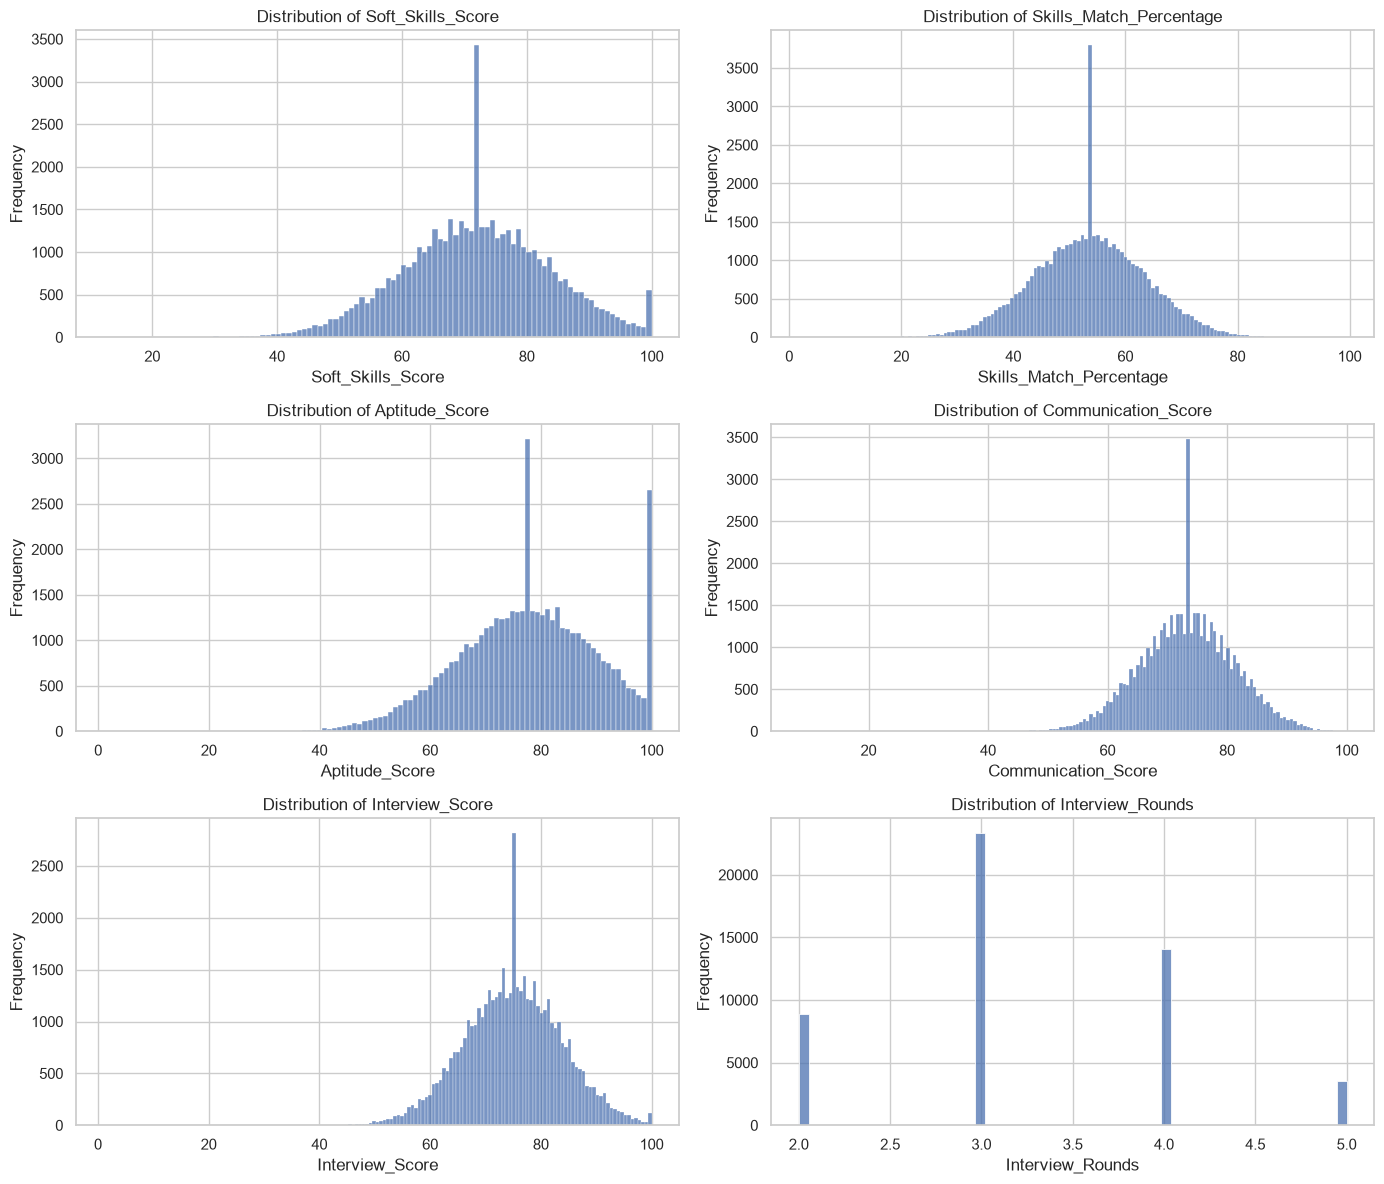

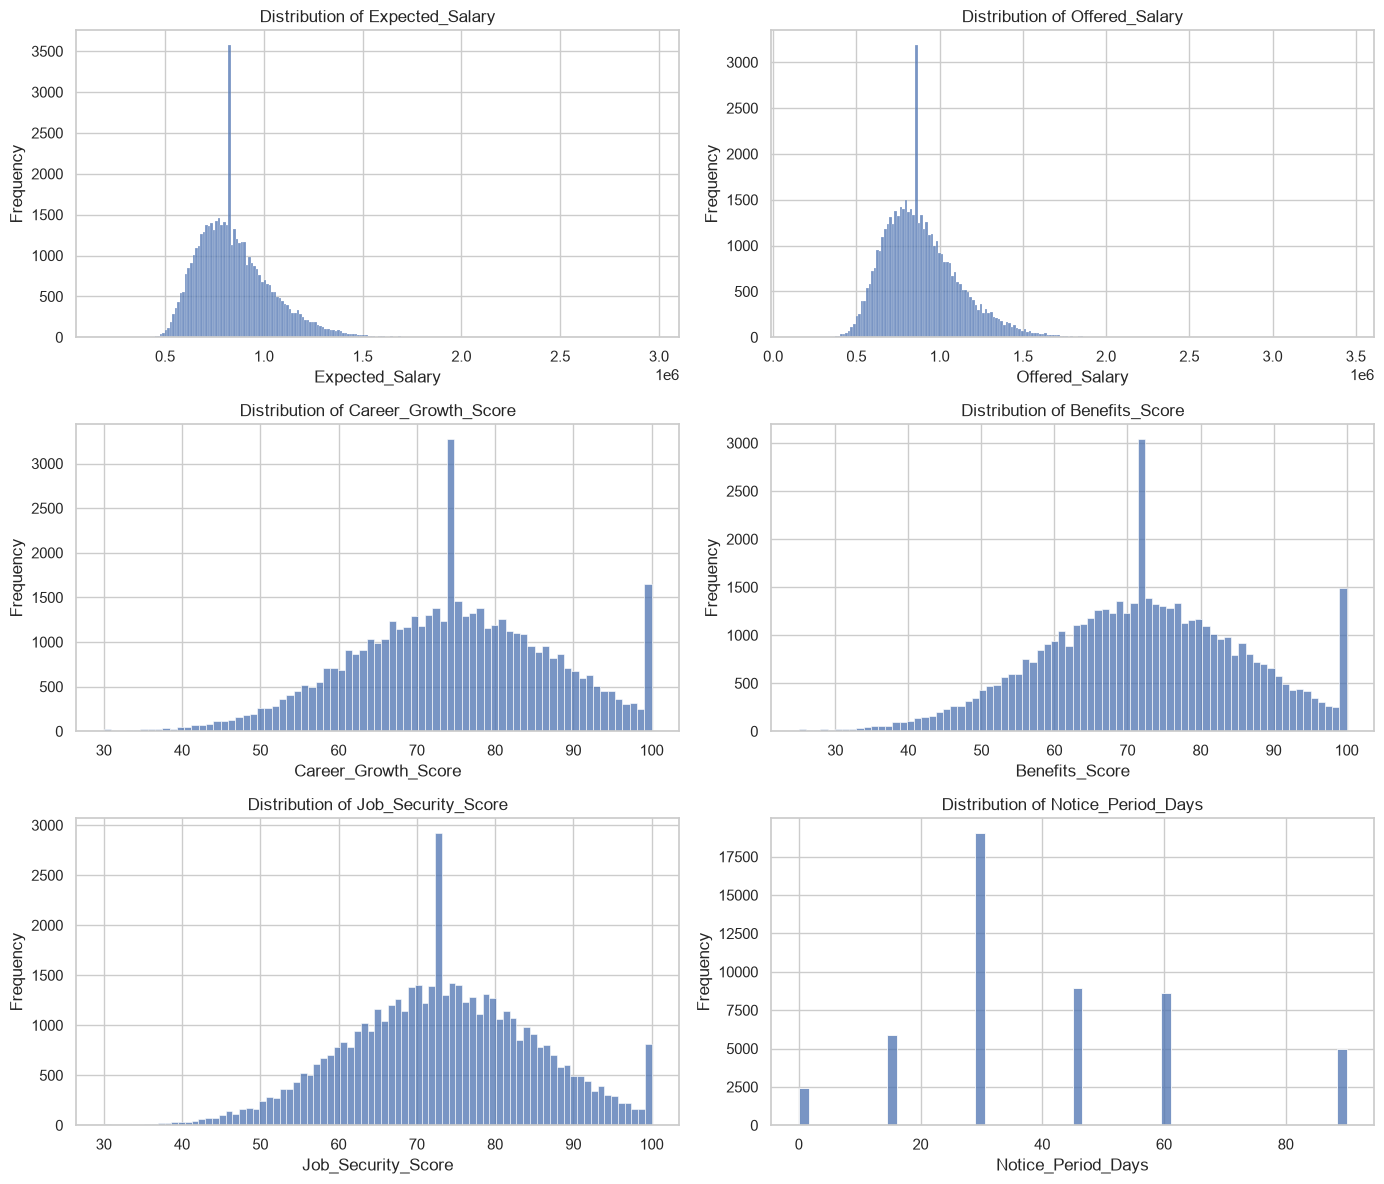

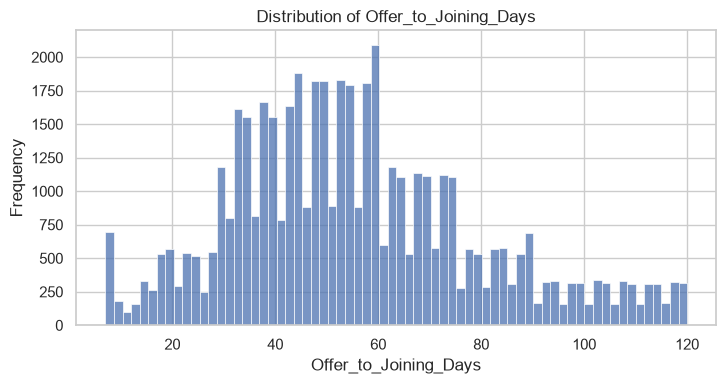

In [7]:
for start in range(0, len(numeric_features), 6):

    cols = numeric_features[start:start + 6]
    rows = int(np.ceil(len(cols) / 2))

    fig, axes = plt.subplots(
        nrows=rows,
        ncols=2,
        figsize=(14, 4 * rows)
    )

    axes = np.atleast_1d(axes).flatten()

    for ax, col in zip(axes, cols):
        # KDE is disabled for speed on the 49K-row dataset.
        sns.histplot(
            data=df,
            x=col,
            kde=False,
            ax=ax
        )

        ax.set_title(f"Distribution of {col}")
        ax.set_xlabel(col)
        ax.set_ylabel("Frequency")

    for ax in axes[len(cols):]:
        ax.remove()

    fig.tight_layout()
    plt.show()
    plt.close(fig)

## 8. Categorical Features

In [8]:
categorical_features = df.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Number of categorical features:", len(categorical_features))
print(categorical_features)

Number of categorical features: 16
['Candidate_ID', 'Gender', 'Education_Level', 'Degree_Field', 'University_Tier', 'Internship_Experience', 'Job_Role', 'Industry', 'Company_Tier', 'Company_Size', 'Job_Type', 'Work_Mode', 'Job_Location', 'Preferred_Location', 'Relocation_Willingness', 'Competition_Level']


## 9. Numerical Features vs Job Acceptance

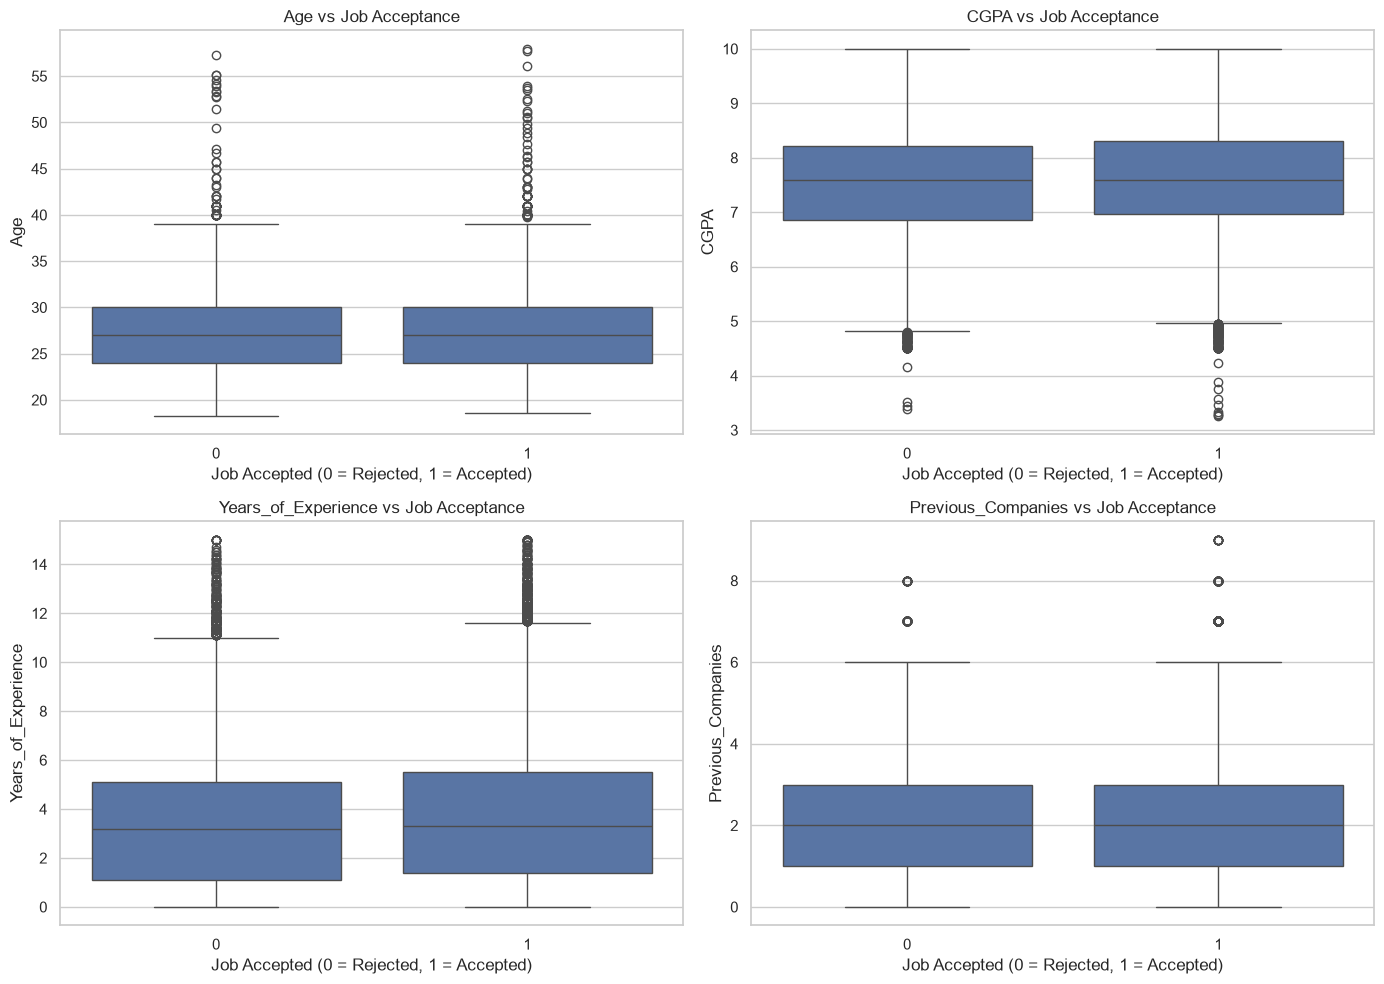

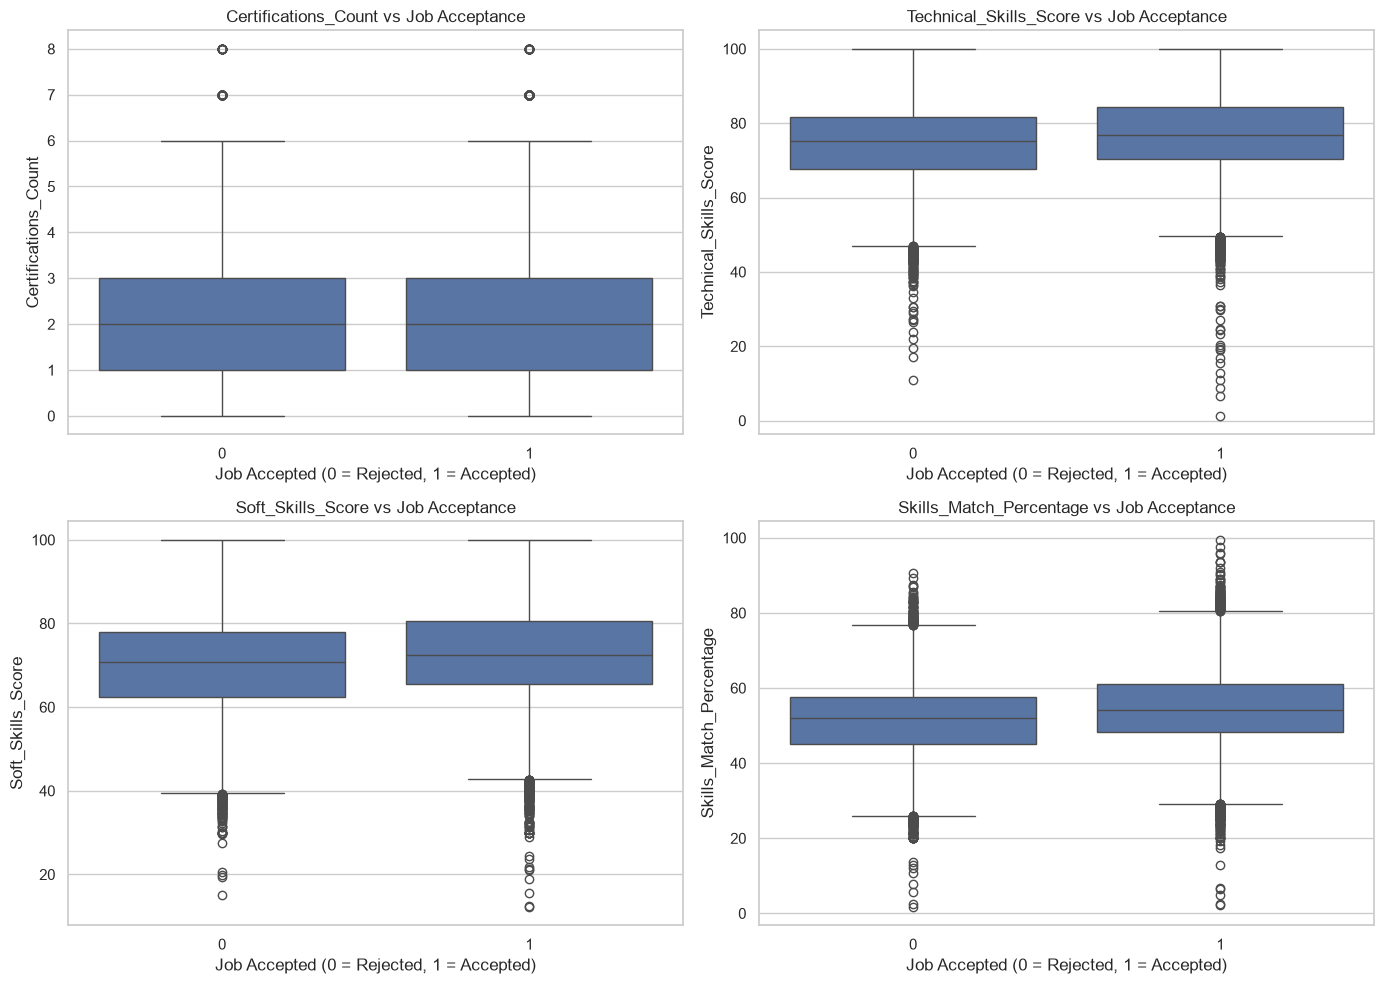

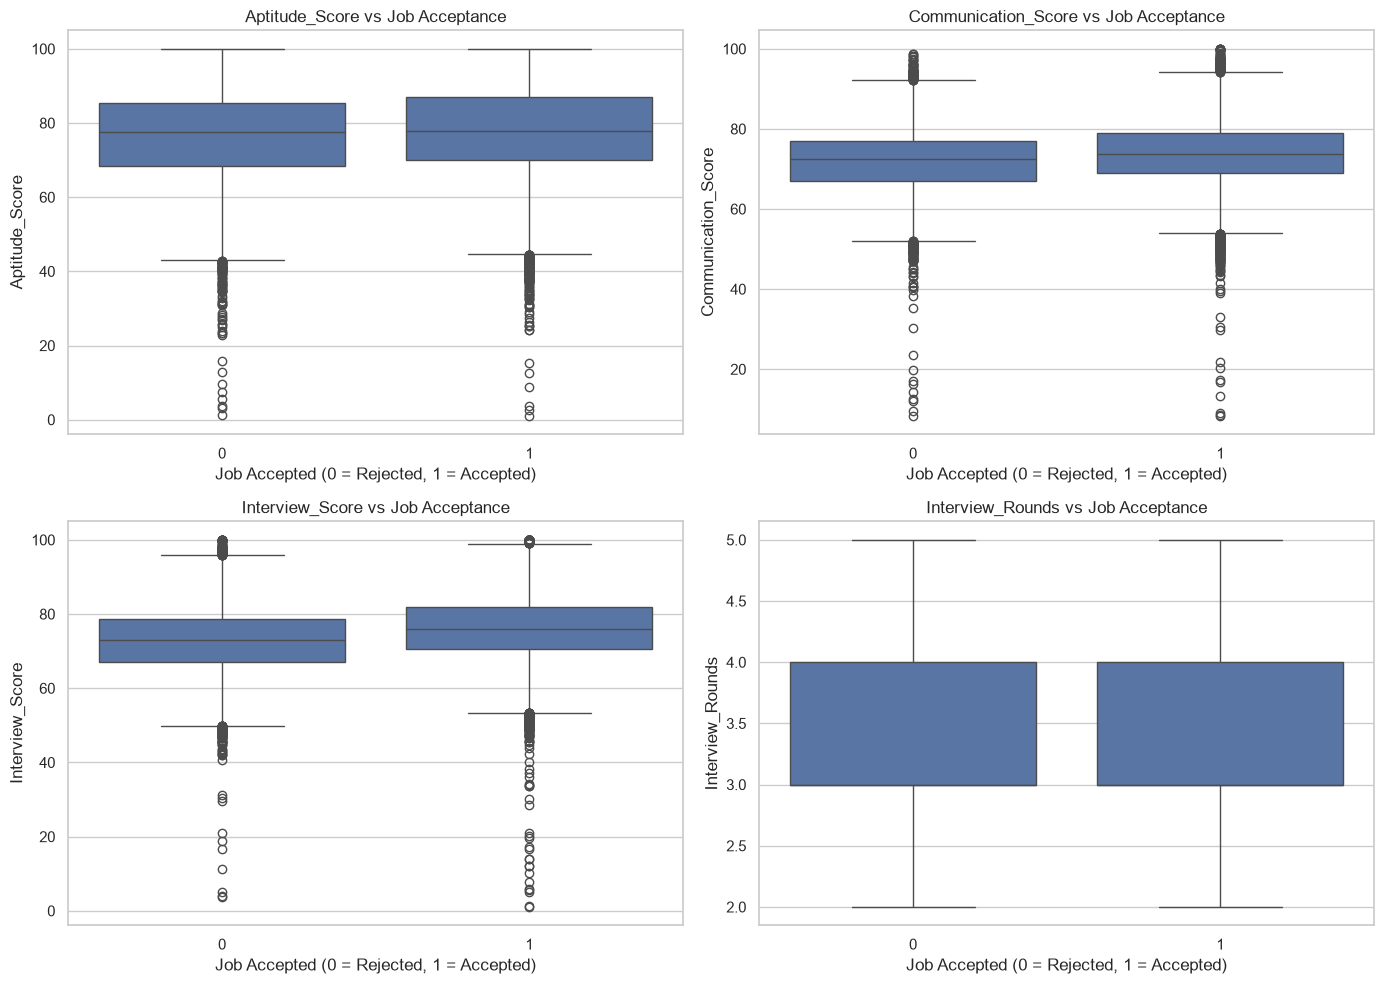

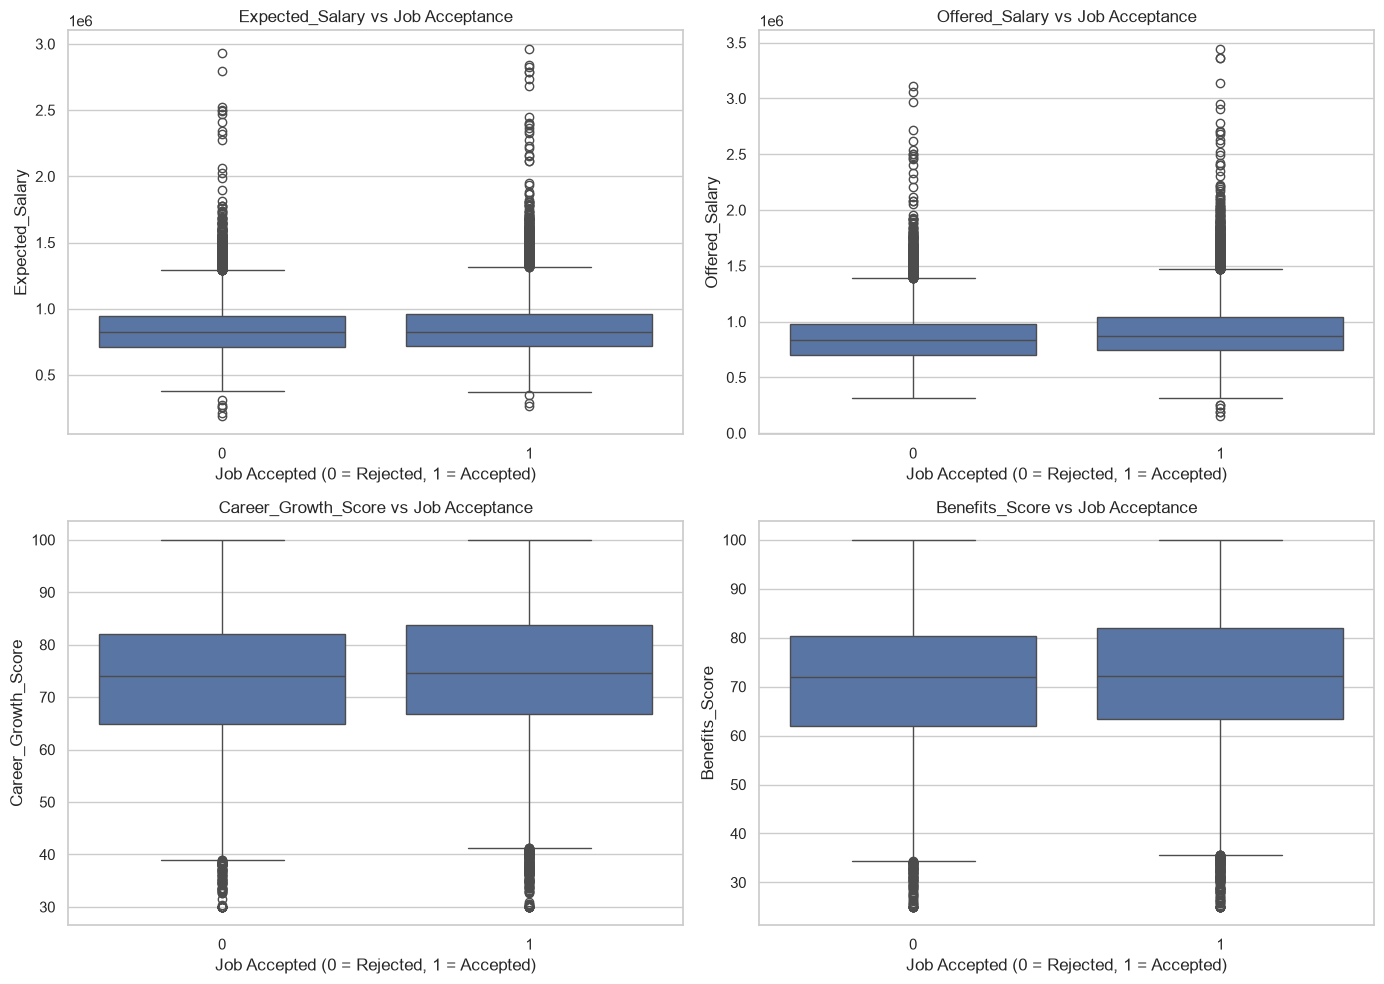

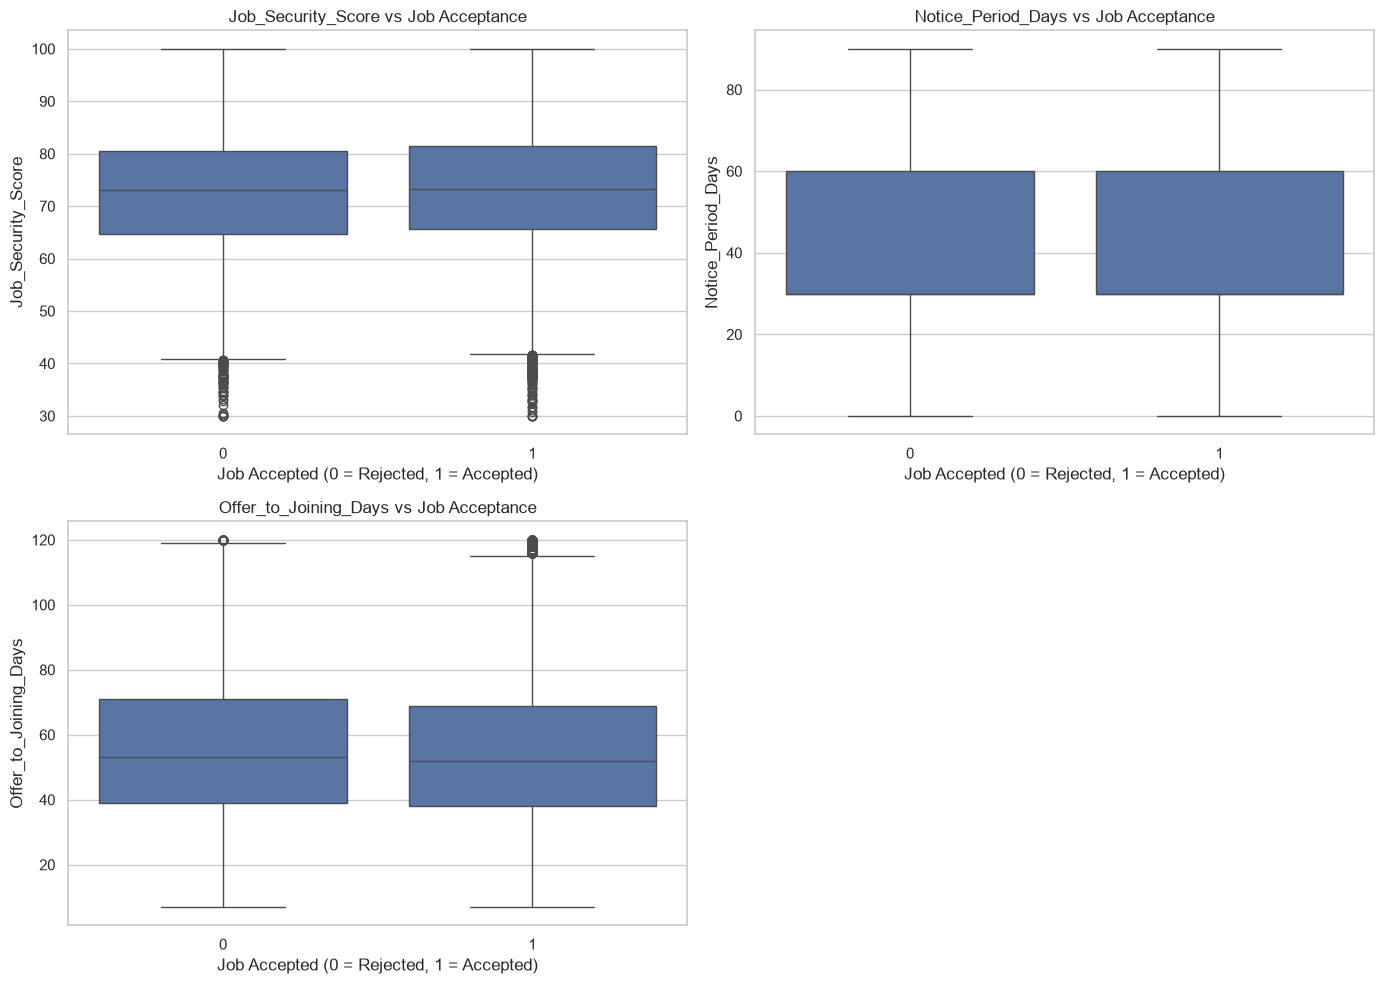

In [9]:
for start in range(0, len(numeric_features), 4):

    cols = numeric_features[start:start + 4]

    fig, axes = plt.subplots(
        nrows=2,
        ncols=2,
        figsize=(14, 10)
    )

    axes = np.atleast_1d(axes).flatten()

    for ax, col in zip(axes, cols):
        sns.boxplot(
            data=df,
            x=target,
            y=col,
            order=[0, 1],
            ax=ax
        )

        ax.set_title(f"{col} vs Job Acceptance")
        ax.set_xlabel("Job Accepted (0 = Rejected, 1 = Accepted)")

    for ax in axes[len(cols):]:
        ax.remove()

    fig.tight_layout()
    plt.show()
    plt.close(fig)

## 10. Mean Comparison — Accepted vs Rejected

In [10]:
mean_comparison = (
    df.groupby(target)[numeric_features]
    .mean()
    .T
)

mean_comparison = mean_comparison.rename(
    columns={
        0: "Rejected_Mean",
        1: "Accepted_Mean"
    }
)

mean_comparison["Absolute_Difference"] = (
    mean_comparison["Accepted_Mean"]
    - mean_comparison["Rejected_Mean"]
)

display(
    mean_comparison.sort_values(
        "Absolute_Difference",
        ascending=False
    )
)

Job_Accepted,Rejected_Mean,Accepted_Mean,Absolute_Difference
Offered_Salary,860241.565415,911206.309526,50964.744111
Expected_Salary,844209.991875,857227.007968,13017.016092
Skills_Match_Percentage,51.428571,54.719854,3.291283
Interview_Score,72.842507,76.107695,3.265188
Soft_Skills_Score,70.215973,72.956109,2.740136
Technical_Skills_Score,74.694675,77.245967,2.551292
Communication_Score,72.148306,73.993441,1.845135
Career_Growth_Score,73.311717,75.154651,1.842933
Benefits_Score,71.145603,72.484413,1.338810
Aptitude_Score,76.812297,78.073651,1.261354


## 11. Correlation Analysis

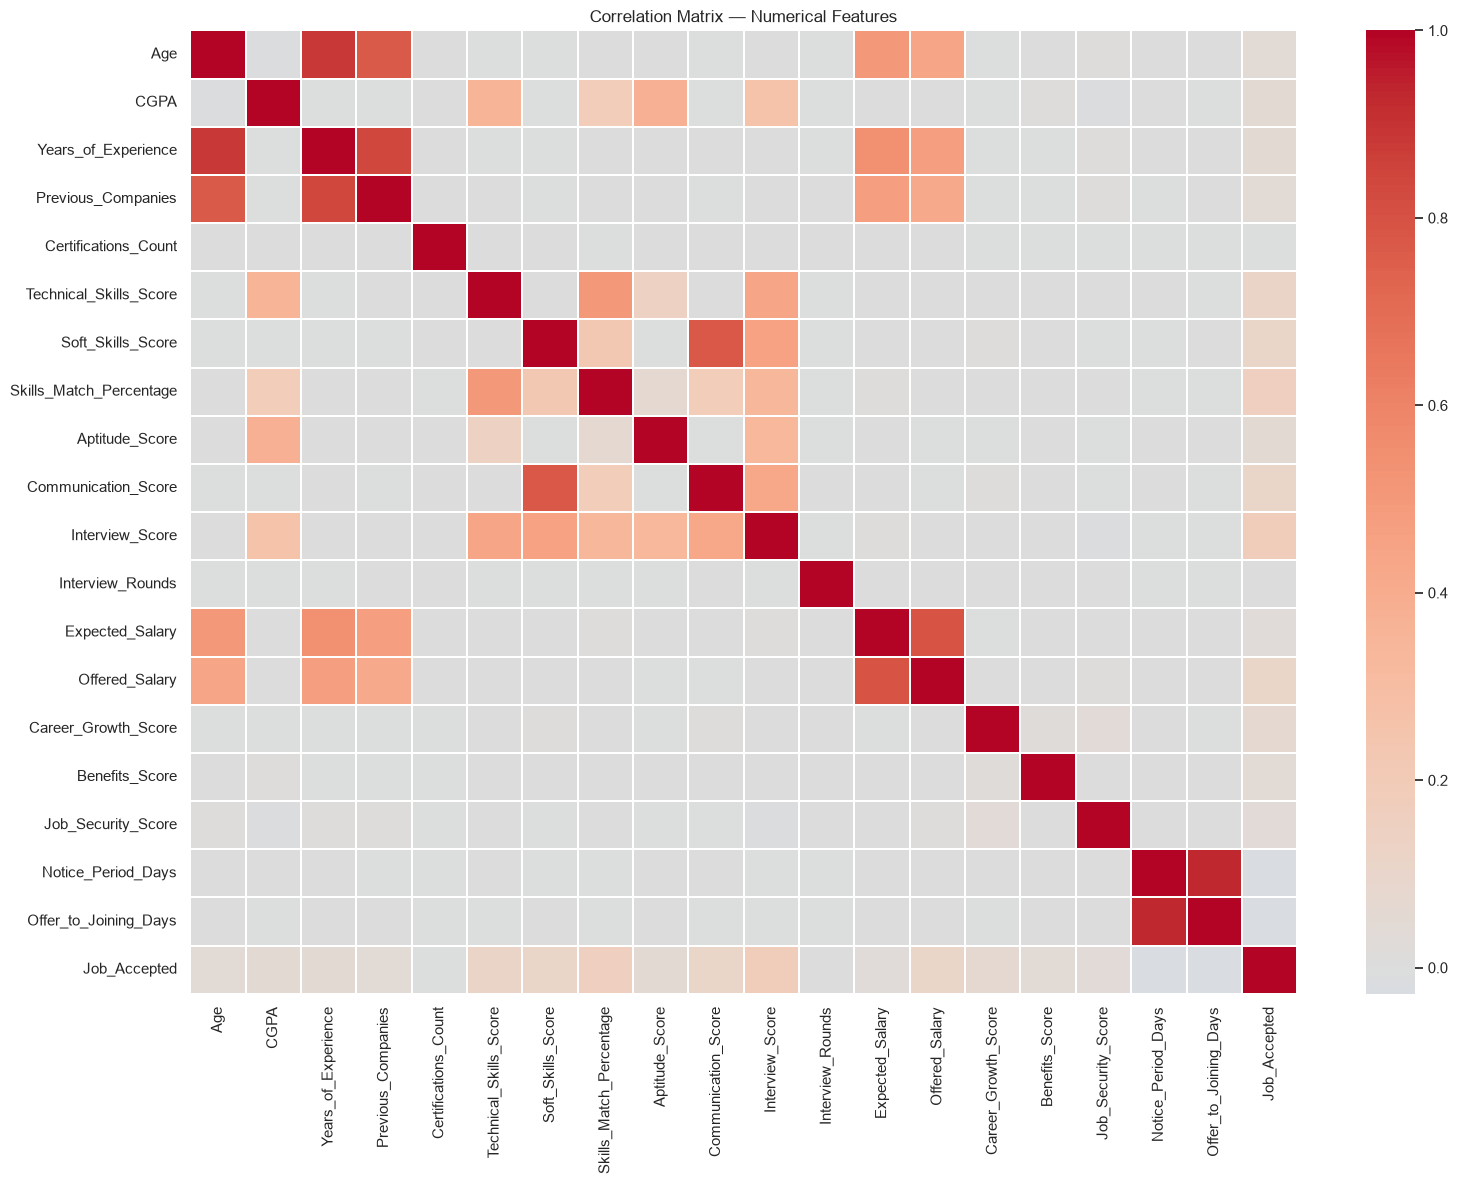

In [11]:
correlation_features = numeric_features + [target]

correlation_matrix = df[correlation_features].corr()

plt.figure(figsize=(16, 12))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0,
    linewidths=0.3
)

plt.title("Correlation Matrix — Numerical Features")
plt.tight_layout()
plt.show()

In [12]:
target_correlations = (
    correlation_matrix[target]
    .drop(target)
    .sort_values(
        key=lambda series: series.abs(),
        ascending=False
    )
)

print("Numerical feature correlations with Job_Accepted:")

display(
    target_correlations.to_frame(
        "Correlation_with_Job_Accepted"
    )
)

Numerical feature correlations with Job_Accepted:


,Correlation_with_Job_Accepted
Interview_Score,0.176746
Skills_Match_Percentage,0.161010
Technical_Skills_Score,0.114762
Soft_Skills_Score,0.112290
Communication_Score,0.112266
Offered_Salary,0.105070
Career_Growth_Score,0.069491
CGPA,0.050999
Years_of_Experience,0.050768
Aptitude_Score,0.048406


## 12. Top Numerical Correlations with Job Acceptance

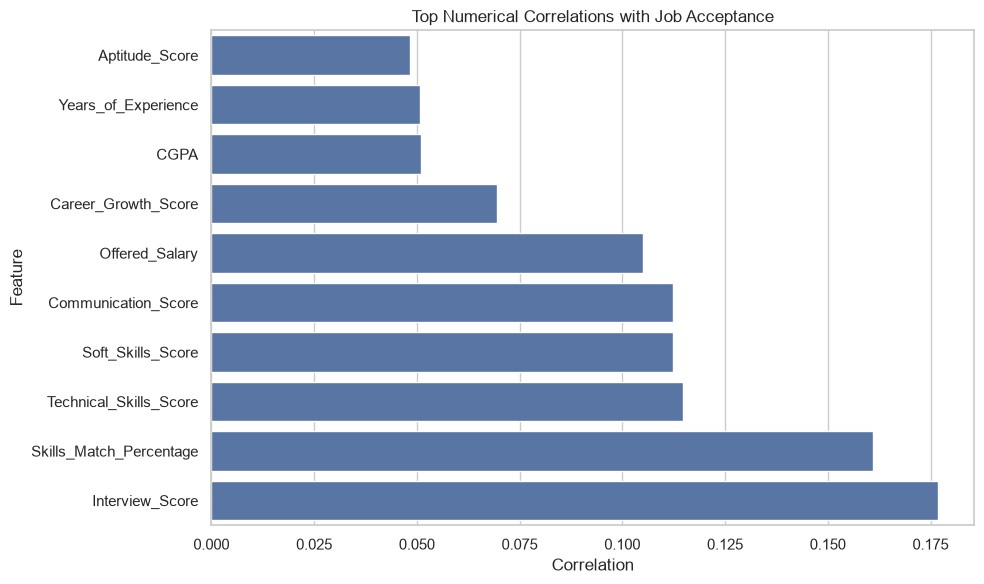

In [13]:
top_n = min(10, len(target_correlations))

top_corr = (
    target_correlations
    .iloc[:top_n]
    .sort_values()
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_corr.values,
    y=top_corr.index
)

plt.title(
    "Top Numerical Correlations with Job Acceptance"
)

plt.xlabel("Correlation")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

## 13. Salary Analysis

In [14]:
salary_candidates = [
    col for col in df.columns
    if any(
        keyword in col.lower()
        for keyword in [
            "salary",
            "ctc",
            "compensation"
        ]
    )
]

print("Salary-related columns found:")
print(salary_candidates)

Salary-related columns found:
['Expected_Salary', 'Offered_Salary']


### Expected_Salary


,count,mean,median,min,max
Job_Accepted,,,,,
0,18025,844209.99,823000.0,190129.87,2932682.80
1,31835,857227.01,823000.0,261692.49,2963087.99


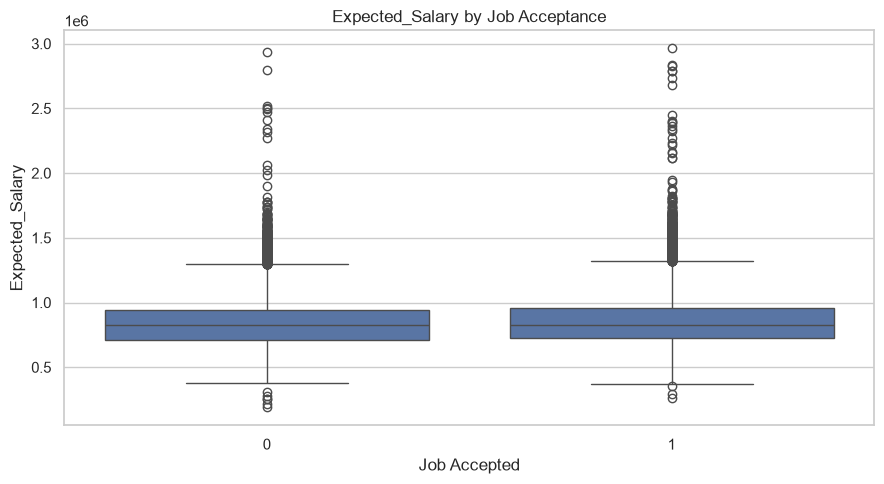

### Offered_Salary


,count,mean,median,min,max
Job_Accepted,,,,,
0,18025,860241.57,834000.0,319000.00,3115455.40
1,31835,911206.31,870000.0,154217.23,3444938.71


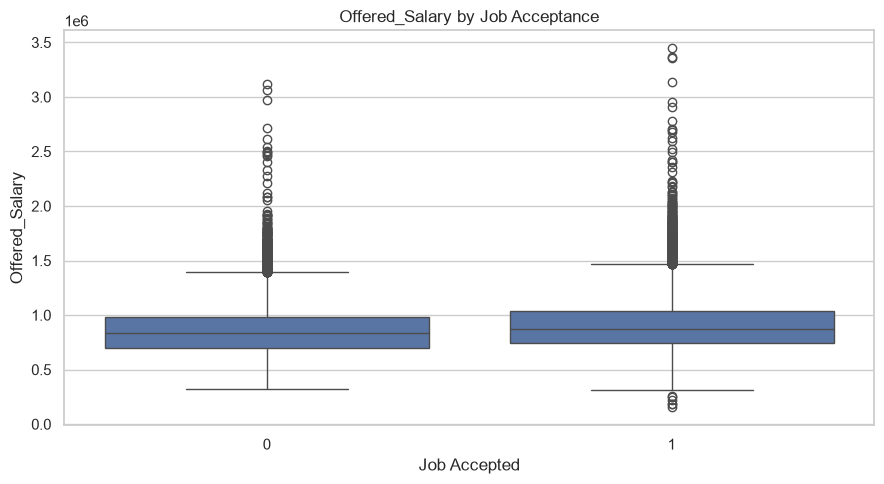

In [15]:
for col in salary_candidates:

    summary = (
        df.groupby(target)[col]
        .agg([
            "count",
            "mean",
            "median",
            "min",
            "max"
        ])
        .round(2)
    )

    print(f"### {col}")
    display(summary)

    plt.figure(figsize=(9, 5))

    sns.boxplot(
        data=df,
        x=target,
        y=col,
        order=[0, 1]
    )

    plt.title(f"{col} by Job Acceptance")
    plt.xlabel("Job Accepted")
    plt.ylabel(col)

    plt.tight_layout()
    plt.show()

## 14. Experience Analysis

In [16]:
experience_cols = [
    col for col in [
        "Years_of_Experience",
        "Previous_Companies",
        "Age"
    ]
    if col in df.columns
]

print("Experience-related columns:")
print(experience_cols)

Experience-related columns:
['Years_of_Experience', 'Previous_Companies', 'Age']


### Years_of_Experience


,mean,median,min,max
Job_Accepted,,,,
0,3.4,3.2,0.0,15.0
1,3.7,3.3,0.0,15.0


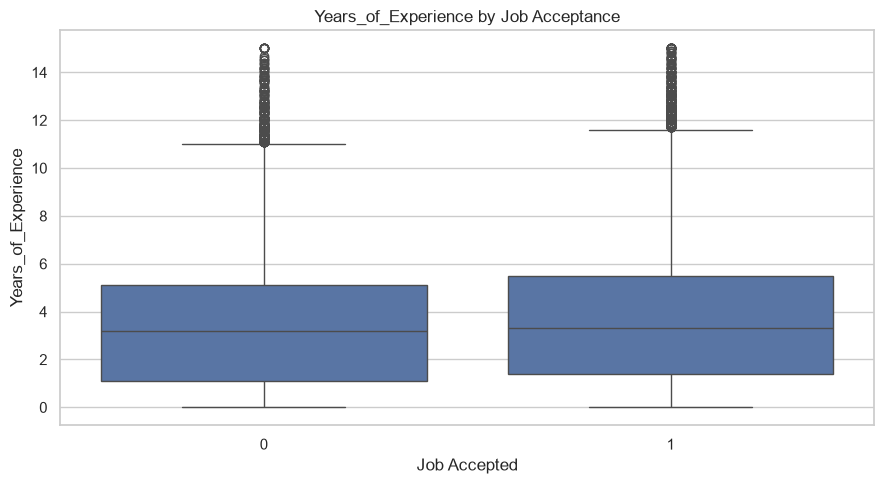

### Previous_Companies


,mean,median,min,max
Job_Accepted,,,,
0,1.78,2.0,0.0,8.0
1,1.92,2.0,0.0,9.0


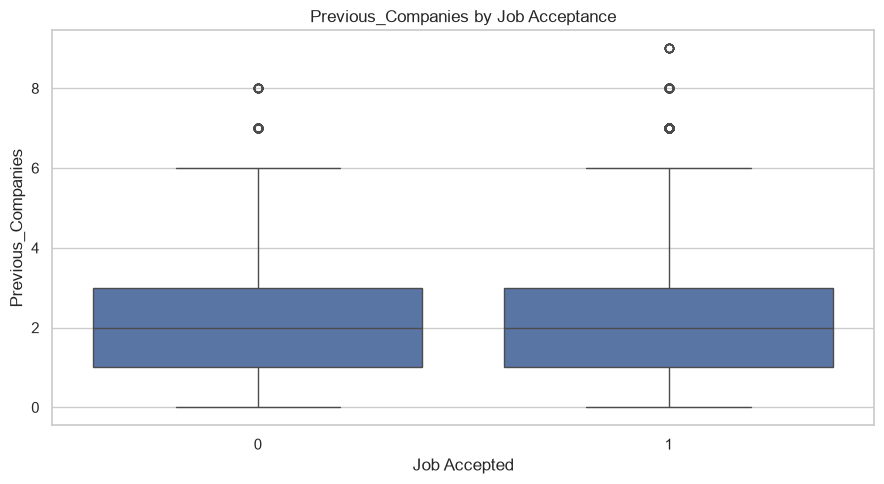

### Age


,mean,median,min,max
Job_Accepted,,,,
0,26.86,27.0,18.27,57.29
1,27.29,27.0,18.59,57.95


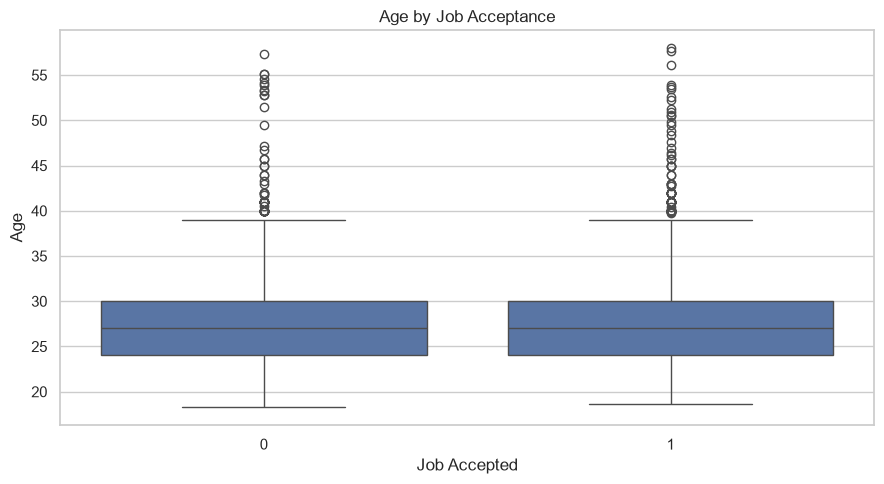

In [17]:
for col in experience_cols:

    grouped = (
        df.groupby(target)[col]
        .agg([
            "mean",
            "median",
            "min",
            "max"
        ])
        .round(2)
    )

    print(f"### {col}")
    display(grouped)

    plt.figure(figsize=(9, 5))

    sns.boxplot(
        data=df,
        x=target,
        y=col,
        order=[0, 1]
    )

    plt.title(f"{col} by Job Acceptance")
    plt.xlabel("Job Accepted")
    plt.ylabel(col)

    plt.tight_layout()
    plt.show()

## 15. Skills and Interview Performance

In [18]:
skills_interview_cols = [
    col for col in [
        "Technical_Skills_Score",
        "Soft_Skills_Score",
        "Skills_Match_Percentage",
        "Aptitude_Score",
        "Communication_Score",
        "Interview_Score",
        "Interview_Rounds",
        "Career_Growth_Score",
        "Benefits_Score",
        "Job_Security_Score"
    ]
    if col in df.columns
]

print("Skills/interview-related columns:")
print(skills_interview_cols)

Skills/interview-related columns:
['Technical_Skills_Score', 'Soft_Skills_Score', 'Skills_Match_Percentage', 'Aptitude_Score', 'Communication_Score', 'Interview_Score', 'Interview_Rounds', 'Career_Growth_Score', 'Benefits_Score', 'Job_Security_Score']


### Technical_Skills_Score


,mean,median
Job_Accepted,,
0,74.69,75.3
1,77.25,76.8


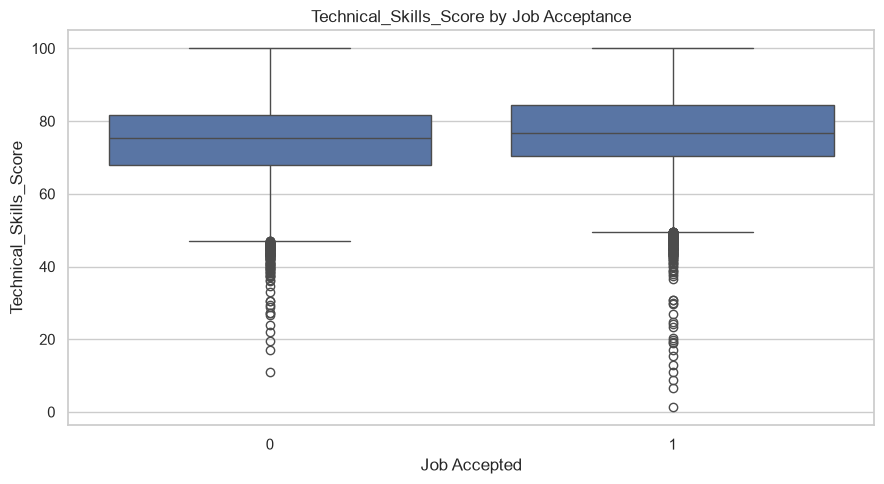

### Soft_Skills_Score


,mean,median
Job_Accepted,,
0,70.22,70.8
1,72.96,72.4


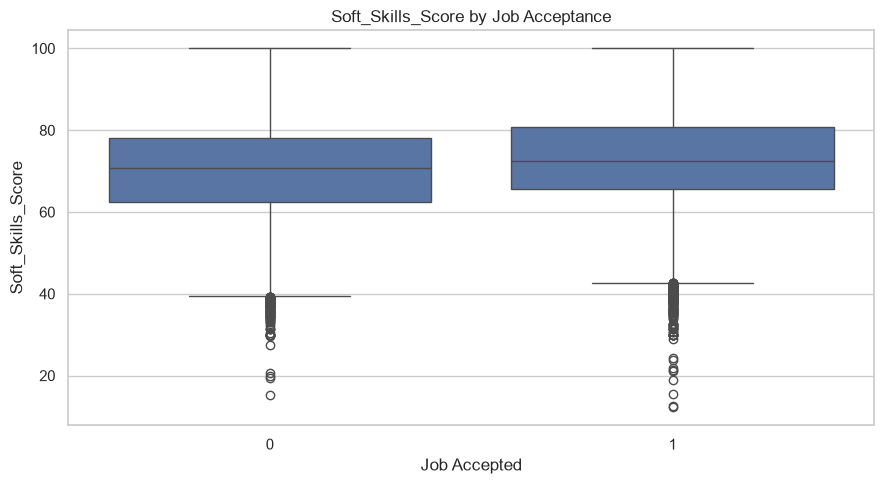

### Skills_Match_Percentage


,mean,median
Job_Accepted,,
0,51.43,52.0
1,54.72,54.2


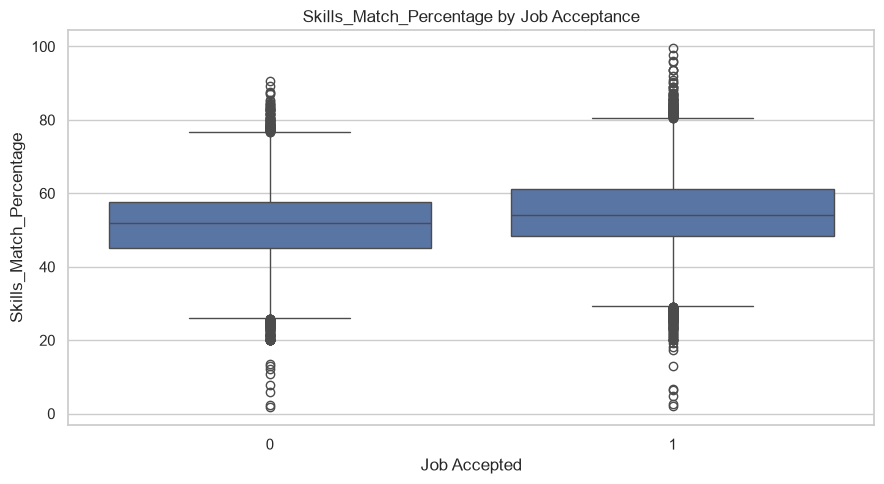

### Aptitude_Score


,mean,median
Job_Accepted,,
0,76.81,77.6
1,78.07,77.9


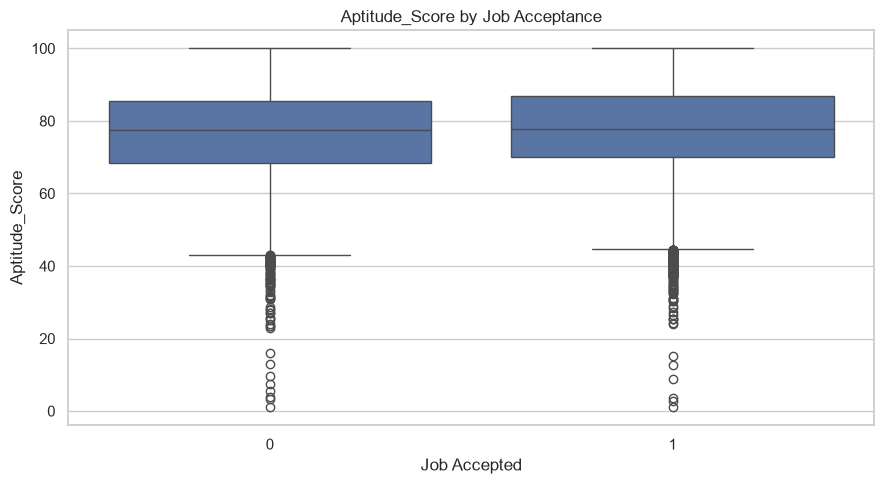

### Communication_Score


,mean,median
Job_Accepted,,
0,72.15,72.6
1,73.99,73.7


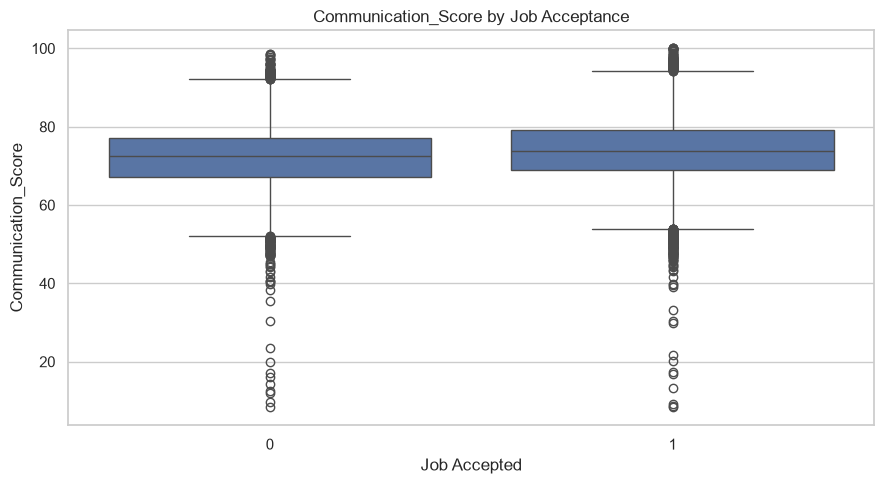

### Interview_Score


,mean,median
Job_Accepted,,
0,72.84,73.1
1,76.11,75.9


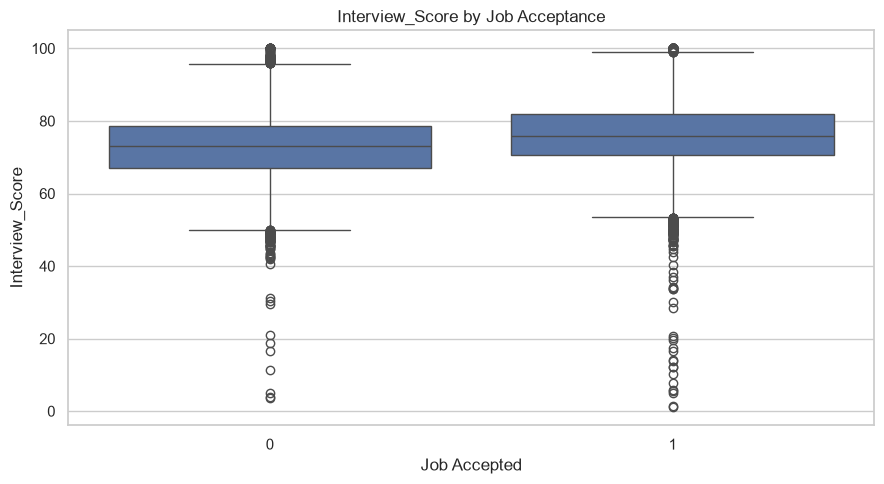

### Interview_Rounds


,mean,median
Job_Accepted,,
0,3.24,3.0
1,3.25,3.0


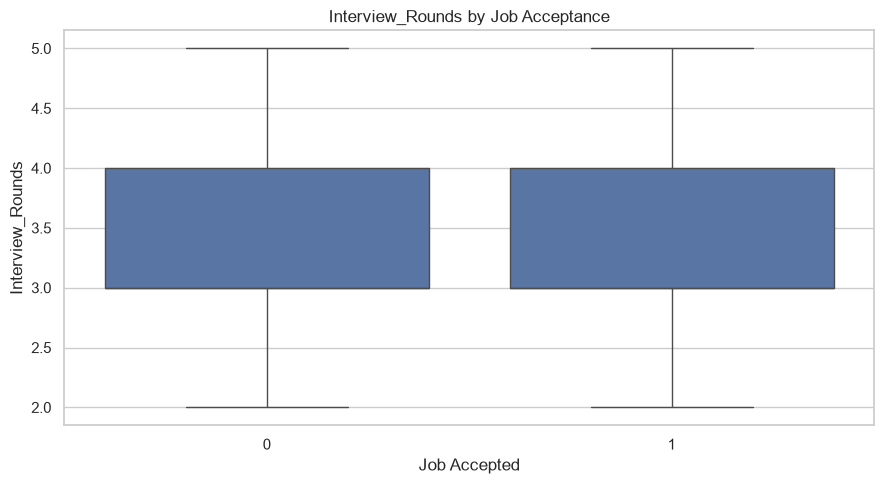

### Career_Growth_Score


,mean,median
Job_Accepted,,
0,73.31,74.1
1,75.15,74.7


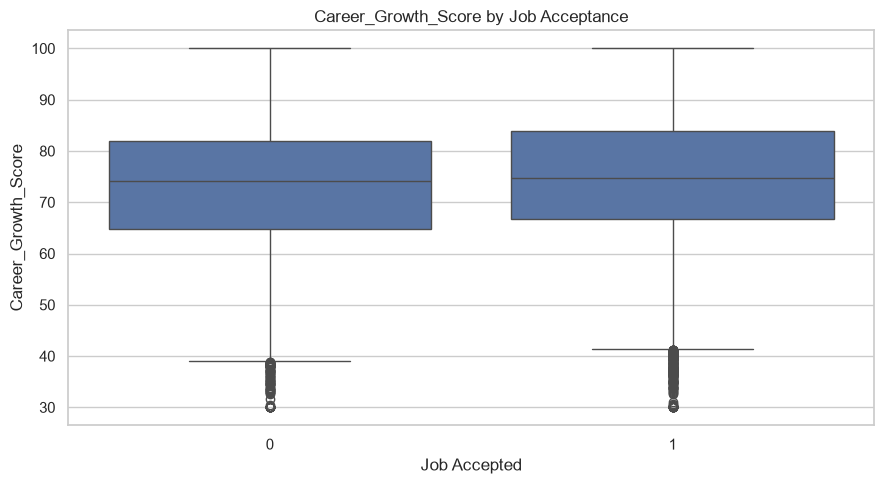

### Benefits_Score


,mean,median
Job_Accepted,,
0,71.15,71.9
1,72.48,72.1


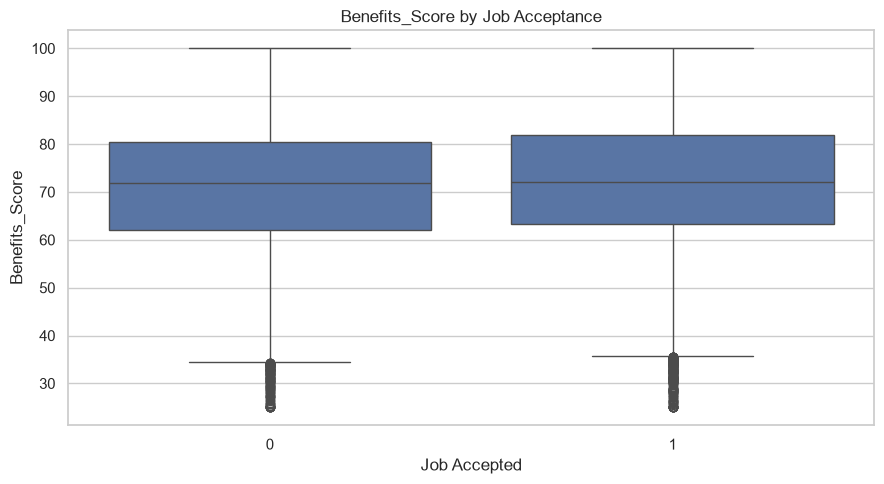

### Job_Security_Score


,mean,median
Job_Accepted,,
0,72.57,73.1
1,73.52,73.2


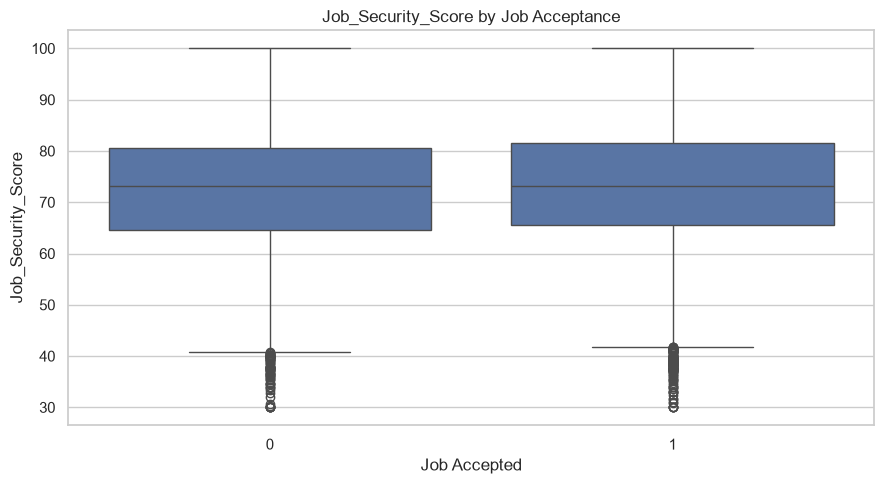

In [19]:
for col in skills_interview_cols:

    grouped = (
        df.groupby(target)[col]
        .agg([
            "mean",
            "median"
        ])
        .round(2)
    )

    print(f"### {col}")
    display(grouped)

    plt.figure(figsize=(9, 5))

    sns.boxplot(
        data=df,
        x=target,
        y=col,
        order=[0, 1]
    )

    plt.title(f"{col} by Job Acceptance")
    plt.xlabel("Job Accepted")
    plt.ylabel(col)

    plt.tight_layout()
    plt.show()

## 16. Acceptance Rate by Score Bands

In [20]:
score_band_candidates = [
    col for col in [
        "Technical_Skills_Score",
        "Soft_Skills_Score",
        "Skills_Match_Percentage",
        "Aptitude_Score",
        "Communication_Score",
        "Interview_Score",
        "Career_Growth_Score",
        "Benefits_Score",
        "Job_Security_Score"
    ]
    if col in df.columns
]

print("Score columns available for band analysis:")
print(score_band_candidates)

Score columns available for band analysis:
['Technical_Skills_Score', 'Soft_Skills_Score', 'Skills_Match_Percentage', 'Aptitude_Score', 'Communication_Score', 'Interview_Score', 'Career_Growth_Score', 'Benefits_Score', 'Job_Security_Score']


### Technical_Skills_Score


,Acceptance_Rate_Percent
Technical_Skills_Score_Band,
Low,49.27
Medium,58.99
High,67.64


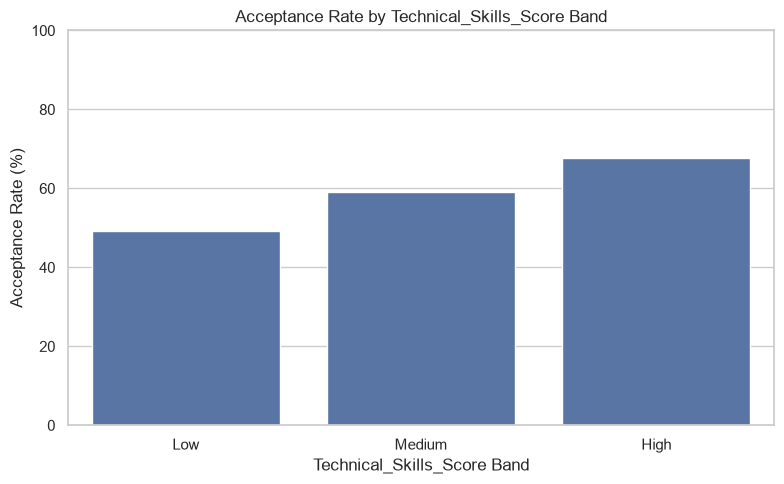

### Soft_Skills_Score


,Acceptance_Rate_Percent
Soft_Skills_Score_Band,
Low,50.93
Medium,61.19
High,68.93


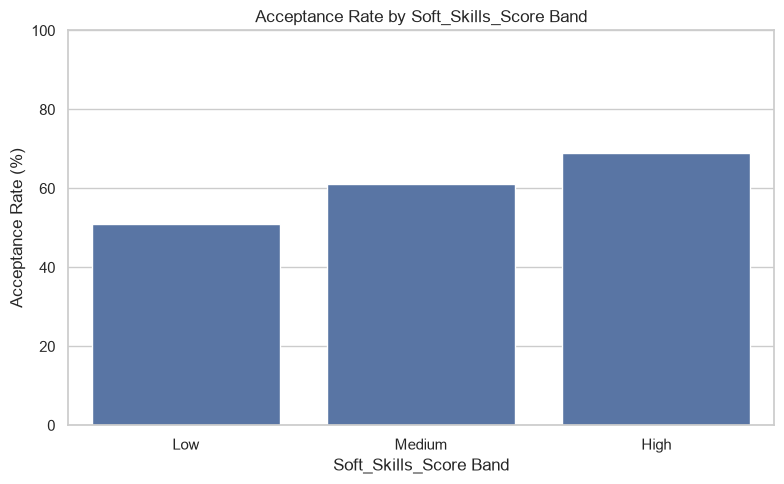

### Skills_Match_Percentage


,Acceptance_Rate_Percent
Skills_Match_Percentage_Band,
Low,55.53
Medium,67.95
High,79.81


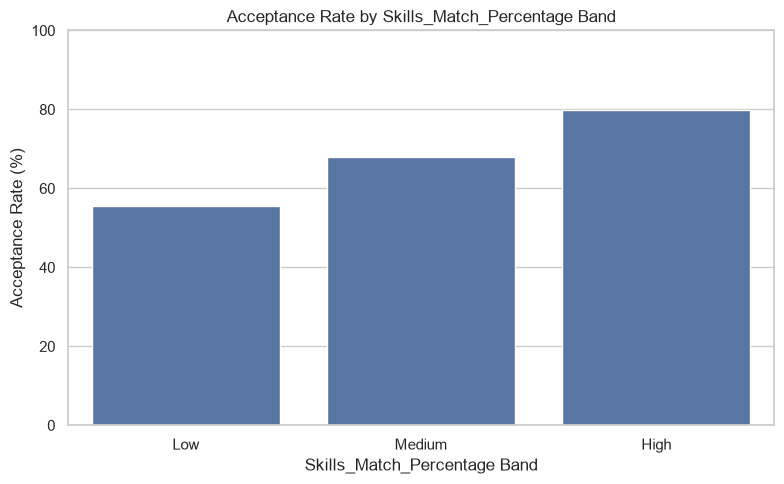

### Aptitude_Score


,Acceptance_Rate_Percent
Aptitude_Score_Band,
Low,59.17
Medium,61.52
High,65.44


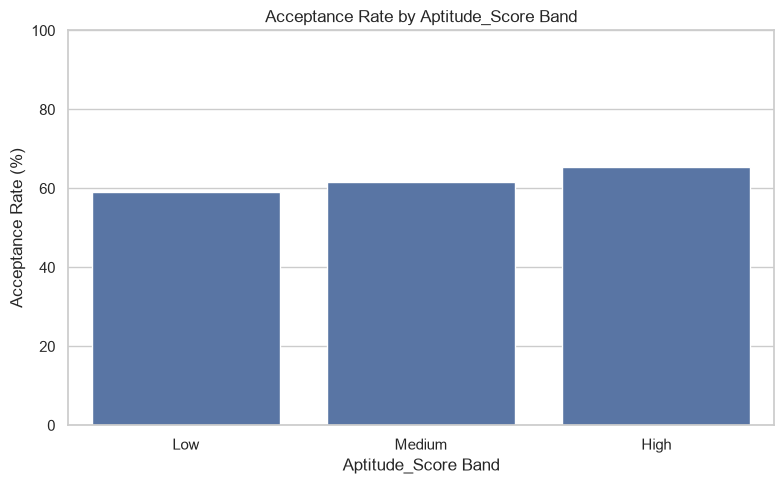

### Communication_Score


,Acceptance_Rate_Percent
Communication_Score_Band,
Low,51.56
Medium,60.18
High,69.28


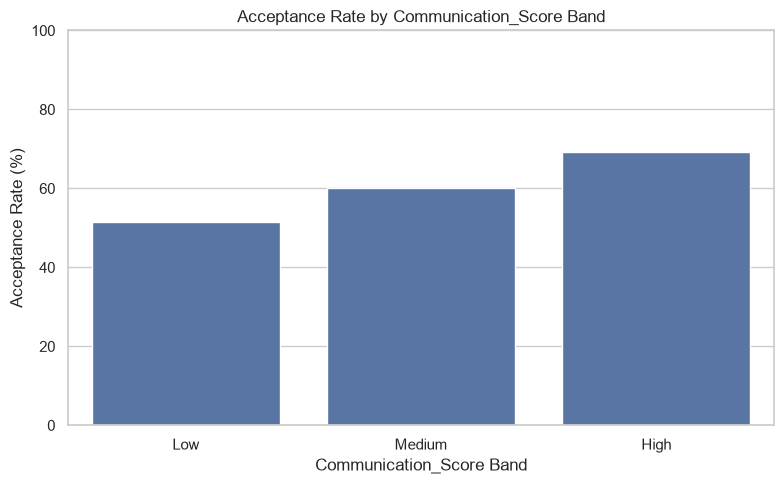

### Interview_Score


,Acceptance_Rate_Percent
Interview_Score_Band,
Low,42.14
Medium,56.83
High,70.54


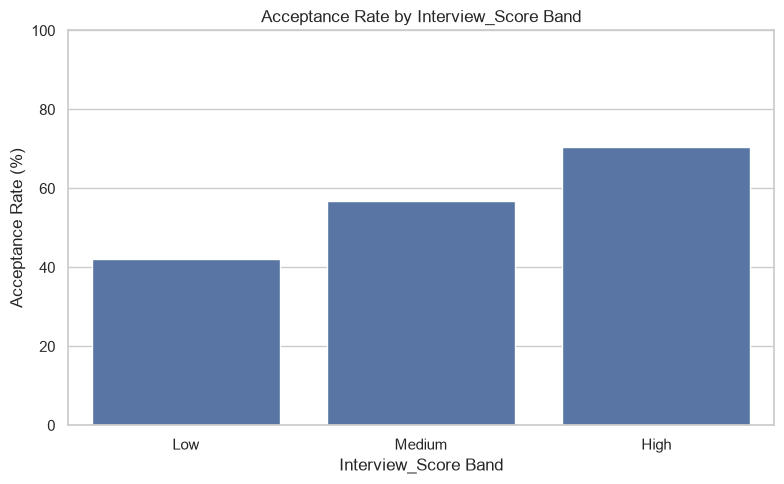

### Career_Growth_Score


,Acceptance_Rate_Percent
Career_Growth_Score_Band,
Low,55.40
Medium,61.72
High,66.64


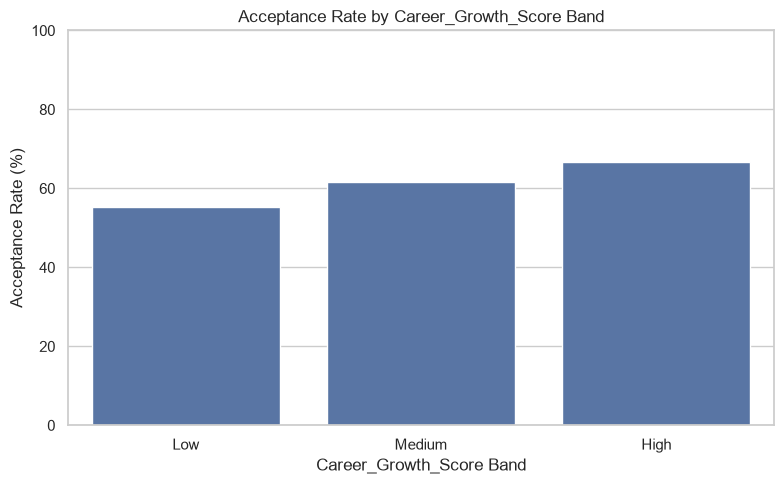

### Benefits_Score


,Acceptance_Rate_Percent
Benefits_Score_Band,
Low,59.71
Medium,62.82
High,65.79


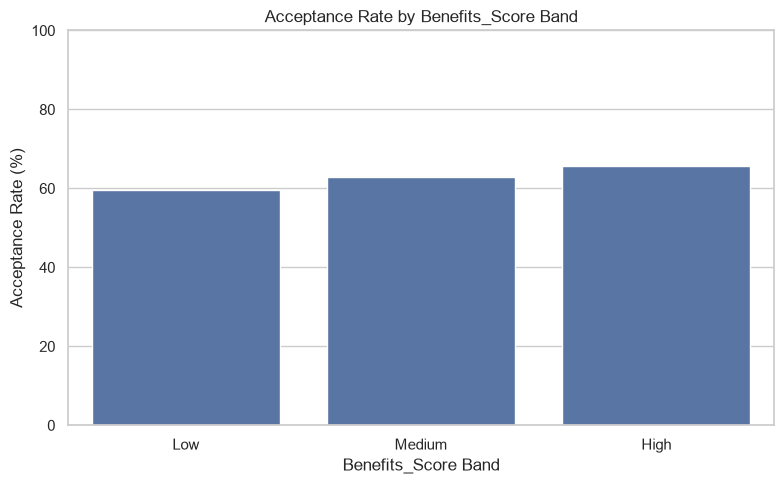

### Job_Security_Score


,Acceptance_Rate_Percent
Job_Security_Score_Band,
Low,59.32
Medium,62.81
High,65.44


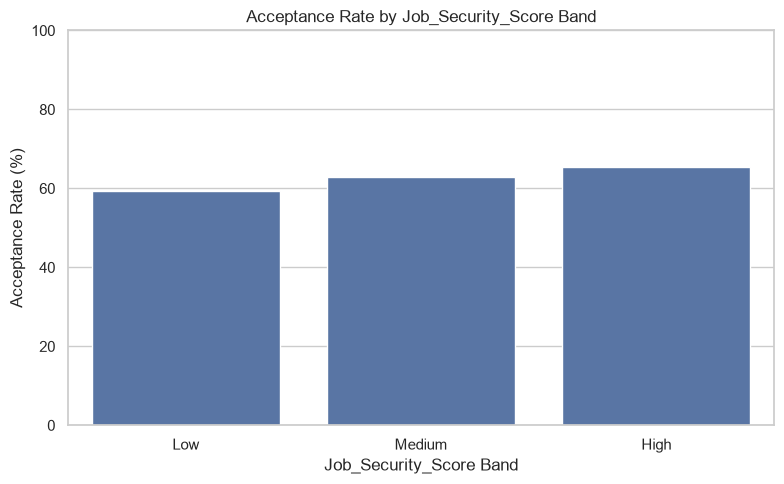

In [21]:
# Score bands are created only for EDA.
# They are NOT automatically added to the modeling dataset.

for col in score_band_candidates:

    band_col = f"{col}_Band"

    df[band_col] = pd.cut(
        df[col],
        bins=[
            -np.inf,
            49.999,
            74.999,
            np.inf
        ],
        labels=[
            "Low",
            "Medium",
            "High"
        ]
    )

    rate = (
        df.groupby(
            band_col,
            observed=False
        )[target]
        .mean()
        .mul(100)
        .round(2)
    )

    print(f"### {col}")

    display(
        rate.rename(
            "Acceptance_Rate_Percent"
        ).to_frame()
    )

    plt.figure(figsize=(8, 5))

    sns.barplot(
        x=rate.index.astype(str),
        y=rate.values
    )

    plt.title(
        f"Acceptance Rate by {col} Band"
    )

    plt.xlabel(f"{col} Band")
    plt.ylabel("Acceptance Rate (%)")
    plt.ylim(0, 100)

    plt.tight_layout()
    plt.show()

## 17. Experience Bands

,Acceptance_Rate_Percent
Experience_Band,
Fresher/Entry,60.72
Junior,63.64
Mid-Level,66.57
Senior,69.02


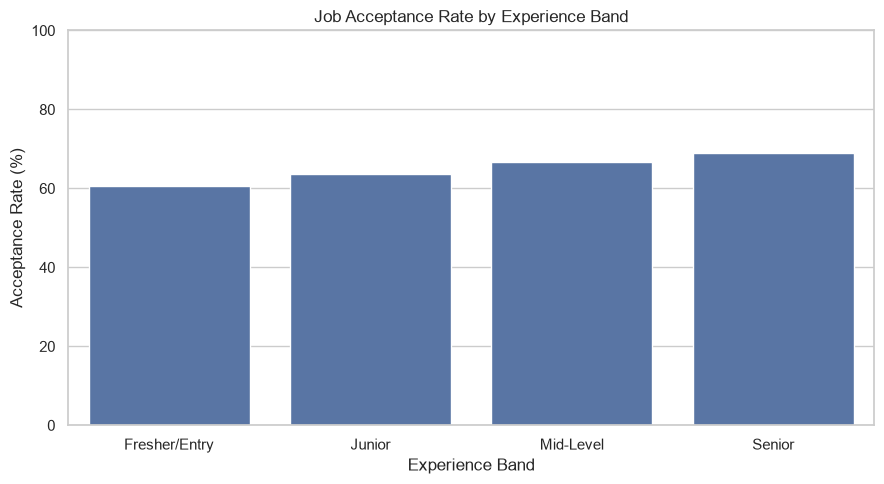

In [22]:
if "Years_of_Experience" in df.columns:

    df["Experience_Band"] = pd.cut(
        df["Years_of_Experience"],
        bins=[
            -np.inf,
            1,
            5,
            10,
            np.inf
        ],
        labels=[
            "Fresher/Entry",
            "Junior",
            "Mid-Level",
            "Senior"
        ]
    )

    experience_rate = (
        df.groupby(
            "Experience_Band",
            observed=False
        )[target]
        .mean()
        .mul(100)
        .round(2)
    )

    display(
        experience_rate.rename(
            "Acceptance_Rate_Percent"
        ).to_frame()
    )

    plt.figure(figsize=(9, 5))

    sns.barplot(
        x=experience_rate.index.astype(str),
        y=experience_rate.values
    )

    plt.title(
        "Job Acceptance Rate by Experience Band"
    )

    plt.xlabel("Experience Band")
    plt.ylabel("Acceptance Rate (%)")
    plt.ylim(0, 100)

    plt.tight_layout()
    plt.show()

## 18. Automated EDA Summary

In [23]:
print("EDA SUMMARY")
print("=" * 70)

print(f"Total candidates: {len(df):,}")
print(f"Total columns: {df.shape[1]:,}")

accepted_rate = df[target].mean() * 100

print(
    f"Overall acceptance rate: "
    f"{accepted_rate:.2f}%"
)

print(
    f"Total missing values: "
    f"{df.isna().sum().sum():,}"
)

print(
    f"Total duplicate rows: "
    f"{df.duplicated().sum():,}"
)

print("\nTop numerical relationships with Job_Accepted:")

for feature, corr in target_correlations.head(5).items():

    print(
        f"  - {feature}: "
        f"correlation = {corr:.3f}"
    )

print("\nEDA completed successfully.")

EDA SUMMARY
Total candidates: 49,860
Total columns: 46
Overall acceptance rate: 63.85%
Total missing values: 0
Total duplicate rows: 0

Top numerical relationships with Job_Accepted:
  - Interview_Score: correlation = 0.177
  - Skills_Match_Percentage: correlation = 0.161
  - Technical_Skills_Score: correlation = 0.115
  - Soft_Skills_Score: correlation = 0.112
  - Communication_Score: correlation = 0.112

EDA completed successfully.


## 19. Save EDA Summary Tables

In [24]:
quality_summary.to_csv(
    OUTPUT_DIR / "eda_data_quality_summary.csv"
)

target_summary.to_csv(
    OUTPUT_DIR / "eda_target_distribution.csv"
)

mean_comparison.to_csv(
    OUTPUT_DIR / "eda_accepted_vs_rejected_means.csv"
)

target_correlations.to_frame(
    "Correlation_with_Job_Accepted"
).to_csv(
    OUTPUT_DIR / "eda_target_correlations.csv"
)

print("EDA summary files saved to:")
print(OUTPUT_DIR)

for file in sorted(OUTPUT_DIR.glob("eda_*.csv")):
    print(" -", file.name)

EDA summary files saved to:
D:\job acceptance prediction system\outputs
 - eda_accepted_vs_rejected_means.csv
 - eda_data_quality_summary.csv
 - eda_target_correlations.csv
 - eda_target_distribution.csv
